# Linear Regression

Linear regression is a fundamental and widely used supervised learning algorithm that models the relationship between a dependent variable (or target variable) and one or more independent variables (or features) by fitting a linear equation to the observed data. The goal is to find the best-fitting straight line (in the case of one independent variable) or hyperplane (in the case of multiple independent variables) that minimizes the difference between the predicted values and the actual values.

### Assumptions of Linear Regression

For linear regression models to be reliable and interpretable, several key assumptions should ideally hold:

1.  **Linearity:** The relationship between the independent and dependent variables is linear. This means that a straight line can adequately represent the pattern in the data.

2.  **Independence of Errors:** The residuals (the differences between the predicted and actual values) are independent of each other. There should be no autocorrelation in the errors.

3.  **Homoscedasticity:** The variance of the errors is constant across all levels of the independent variables. The spread of the residuals should be roughly the same for all predicted values.

4.  **Normality of Errors:** The residuals are normally distributed. This assumption is particularly important for hypothesis testing and constructing confidence intervals.

5.  **No or Little Multicollinearity:** In multiple linear regression, the independent variables should not be highly correlated with each other. High multicollinearity can make it difficult to determine the individual effect of each predictor on the dependent variable.

It's important to note that real-world data rarely perfectly satisfies all these assumptions. However, understanding these assumptions helps in diagnosing potential issues with the model and deciding on appropriate transformations or alternative modeling techniques.

### Limitations of Linear Regression

Despite its simplicity and interpretability, linear regression has certain limitations:

1.  **Sensitive to Outliers:** Outliers, which are data points that deviate significantly from the general pattern, can have a disproportionate influence on the fitted regression line, potentially leading to a biased model.
2.  **Limited for Complex Patterns:** It may not be suitable for modeling complex patterns in the data, especially those with intricate interactions between variables.

### Simple Linear Regression

Simple linear regression involves only one independent variable ($X$) and one dependent variable ($Y$). The model can be represented by the equation:

$$Y = \beta_0 + \beta_1 X + \epsilon$$

where:

  - $Y$ is the dependent variable.
  - $X$ is the independent variable.
  - $\beta_0$ is the y-intercept (the value of $Y$ when $X$ is 0).
  - $\beta_1$ is the slope (the change in $Y$ for a one-unit change in $X$).
  - $\epsilon$ is the error term (the random variation in $Y$ not explained by the linear relationship with $X$).

Let's create a simple example using numpy and scikit-learn:

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
np.random.seed(0)
X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1)

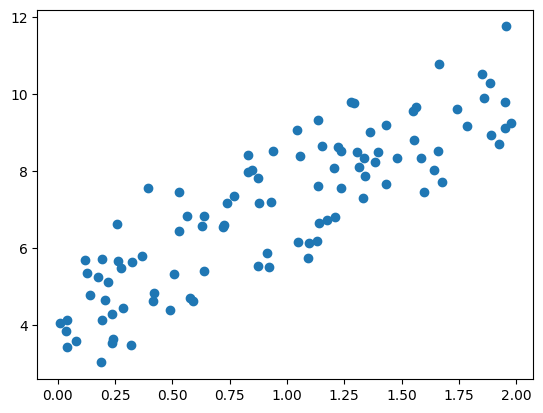

In [3]:
plt.scatter(X[:, 0], y);

In [4]:
# Create a linear regression model
model = LinearRegression()

# Train the model
model.fit(X, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [5]:
# Make predictions on the test set
y_pred = model.predict(X)

In [6]:
model.intercept_[0]

np.float64(4.222151077447231)

In [7]:
model.coef_

array([[2.96846751]])

In [8]:
# Print the coefficients
print(f"Intercept: {model.intercept_[0]:.2f}")
print(f"Slope: {model.coef_[0][0]:.2f}")

Intercept: 4.22
Slope: 2.97


#### Evaluating the Regression Model

Several metrics are used to evaluate the performance of a simple linear regression model:

1.  **Mean Absolute Error (MAE):** This calculates the average of the absolute differences between the predicted and actual values. It provides a measure of the average magnitude of the errors.
    $$MAE = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|$$
    where $y_i$ is the actual value, $\hat{y}_i$ is the predicted value, and $n$ is the number of data points.

2.  **Mean Squared Error (MSE):** This calculates the average of the squared differences between the predicted and actual values. Lower MSE indicates a better fit.
    $$MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$
    where $y\_i$ is the actual value, $\\hat{y}\_i$ is the predicted value, and $n$ is the number of data points.

3.  **Root Mean Squared Error (RMSE):** This is the square root of the MSE and provides an error metric in the same units as the dependent variable, making it more interpretable.
    $$RMSE = \sqrt{MSE}$$

4.  **R-squared (Coefficient of Determination):** This metric represents the proportion of the variance in the dependent variable that is predictable from the independent variable(s). It ranges from 0 to 1, where a higher value generally indicates a better fit.
    $$R^2 = 1 - \frac{\sum_{i=1}^{n} (y_i - \hat{y}_i)^2}{\sum_{i=1}^{n} (y_i - \bar{y})^2}$$
    where $\bar{y}$ is the mean of the actual values.

In [9]:
# Evaluate the model
mae = mean_absolute_error(y, y_pred)
mse = mean_squared_error(y, y_pred)
rmse = mse**0.5
r2 = r2_score(y, y_pred)

print(f"Mean Absolute Error: {mae:.2f}")
print(f"Mean Squared Error: {mse:.2f}")
print(f"Root Mean Squared Error: {rmse:.2f}")
print(f"R-squared: {r2:.2f}")

Mean Absolute Error: 0.85
Mean Squared Error: 0.99
Root Mean Squared Error: 1.00
R-squared: 0.75


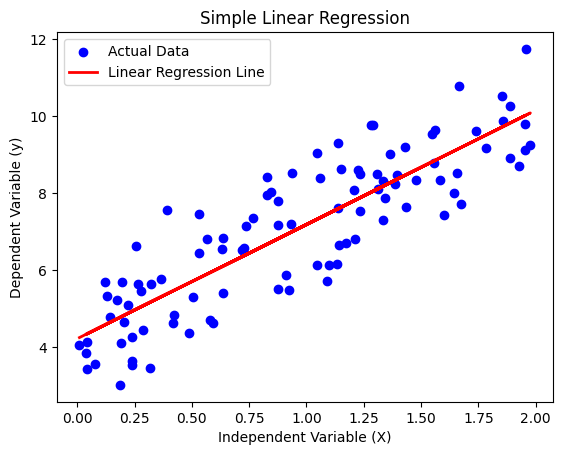

In [10]:
# Plot the results
plt.scatter(X, y, color='blue', label='Actual Data')
plt.plot(X, y_pred, color='red', linewidth=2, label='Linear Regression Line')
plt.xlabel('Independent Variable (X)')
plt.ylabel('Dependent Variable (y)')
plt.title('Simple Linear Regression')
plt.legend();

### Multiple Linear Regression

Multiple linear regression extends simple linear regression to model the relationship between a dependent variable ($Y$) and two or more independent variables ($X\_1, X\_2, ..., X\_p$). The model is represented by the equation:

$$Y = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + ... + \beta_p X_p + \epsilon$$

where:

  - $Y$ is the dependent variable.
  - $X\_1, X\_2, ..., X\_p$ are the independent variables.
  - $\beta_0$ is the y-intercept.
  - $\beta_1, \beta_2, ..., \beta_p$ are the coefficients representing the change in $Y$ for a one-unit change in the corresponding independent variable, holding other variables constant.
  - $\epsilon$ is the error term.

Here's an example using numpy and scikit-learn:

In [11]:
n_samples = 100
X1 = 2 * np.random.rand(n_samples, 1)
X2 = 3 * np.random.rand(n_samples, 1)
y = 5 + 2 * X1 + 1.5 * X2 + np.random.randn(n_samples, 1)

X = np.hstack((X1, X2))

In [12]:
# Create a linear regression model
model = LinearRegression()

# Train the model
model.fit(X, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [13]:
# Make predictions
y_pred = model.predict(X)

In [14]:
# Print the coefficients
print(f"Intercept: {model.intercept_[0]:.2f}")
print(f"Coefficients (beta1, beta2): {model.coef_[0]}")

Intercept: 4.92
Coefficients (beta1, beta2): [2.12052741 1.38051226]


The same evaluation metrics used for simple linear regression (MAE, MSE, RMSE, and R-squared) are also used for multiple linear regression.

In [15]:
# Evaluate the model
mae = mean_absolute_error(y, y_pred)
mse = mean_squared_error(y, y_pred)
rmse = mse**0.5
r2 = r2_score(y, y_pred)

print(f"Mean Absolute Error: {mae:.2f}")
print(f"Mean Squared Error: {mse:.2f}")
print(f"Root Mean Squared Error: {rmse:.2f}")
print(f"R-squared: {r2:.2f}")

Mean Absolute Error: 0.79
Mean Squared Error: 0.96
Root Mean Squared Error: 0.98
R-squared: 0.75


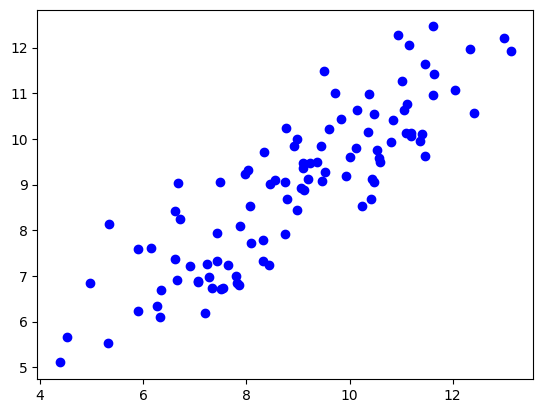

In [16]:
# Plot predictions against actual values

plt.scatter(y, y_pred, color='blue');

Linear regression is a powerful and interpretable algorithm for modeling linear relationships between variables. Understanding its assumptions and limitations is crucial for applying it effectively. Simple linear regression deals with one independent variable, while multiple linear regression handles multiple predictors. Evaluating the model's performance using metrics like MAE, MSE, RMSE, and R-squared (and adjusted R-squared for multiple regression) helps in determining the quality of the fit and the reliability of the predictions. While it may not be suitable for all types of data or complex relationships, linear regression remains a fundamental tool in the machine learning toolkit and often serves as a baseline model for more advanced techniques.

# Logistic Regression

Logistic Regression is a fundamental supervised machine learning algorithm primarily used for binary classification tasks where the target variable can be Yes/No or True/False. Despite its name, it's a classification algorithm, not a regression one. It models the probability that a given input point belongs to a particular class/group. While it can be extended to multi-class classification, its core application lies in distinguishing between two classes.

Logistic Regression works by fitting a linear model to the log odds of the target variable, the predicted log odds are then converted to probabilities using the sigmoid (logistic) function. This probability is then used to classify the instance.

### Assumptions of Logistic Regression

In other to ensure that the algorithm is used correctly, we must understand the following assumptions about the algorithm.

* **Binary Outcome**: The dependent variable must be binary (two classes).
* **Independence of Observations**: Each observation should be independent of others.
* **No Multicollinearity**: Independent variables should not be highly correlated with each other. High multicollinearity can lead to unstable and unreliable coefficient estimates.
* **Linearity of Log-Odds**: The independent variables are linearly related to the log-odds (logit) of the outcome. This means the relationship between the features and the logarithm of the odds of the outcome belonging to the positive class is linear.
* **Large Sample Size**: Logistic Regression tends to perform better with larger sample sizes.

### The Sigmoid (Logistic) Function
The sigmoid function is an important part of logistic regression which is used to convert the output of the underlying regression model of into a probability value between 0 and 1. 

The function takes any real number, in the case of Logistic Regression, the Log Odds and converts it into a real number (probabilities) between 0 and 1. These probality values are then used to determine the class that an instance or observation belongs to. Whenever the output of the sigmoid function is greater or equal 0.5, the class is often predicted as Yes/True and No/False if otherwise.

The formula for the sigmoid function, denoted as $\sigma(z)$, is:

$$ \sigma(z) = \frac{1}{1 + e^{-z}} $$

Where:
* z is a linear combination of the input features and their corresponding weights (similar to linear regression): $z = \beta_0 + \beta_1x_1 + \beta_2x_2 + \cdots + \beta_nx_n = B^TX$
* $e$ is Euler's number (approximately 2.71828)

The output of the sigmoid function is always between 0 and 1, inclusive ($0 \leq \sigma(z) \leq 1$). This makes it ideal for representing probabilities. The function also produces an S-shaped curve. As $z$ approaches positive infinity, $\sigma(z)$ approaches 1. As $z$ approaches negative infinity, $\sigma(z)$ approaches 0. When $z=0$, $\sigma(z)=0.5$.

In [17]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

<Axes: xlabel='z', ylabel='S(z)'>

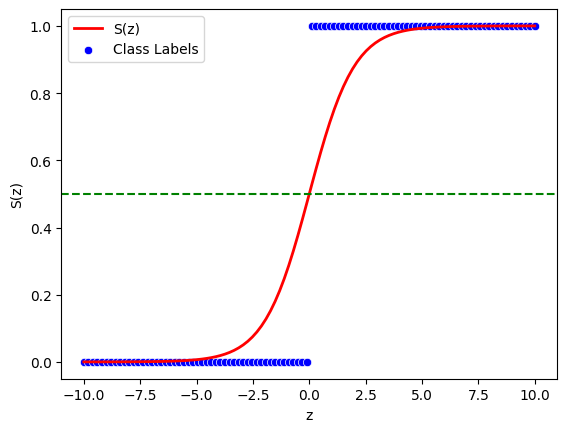

In [18]:
z = np.linspace(-10, 10, 100)
sigmoid_z = 1 / (1 + np.exp(-z))
class_labels = np.where(sigmoid_z > 0.5, 1, 0)

sns.lineplot(x=z, y=sigmoid_z, color='red', linewidth=2, label="S(z)")
plt.ylabel("S(z)")
plt.xlabel("z")
plt.axhline(0.5, color='green', linestyle='--')
sns.scatterplot(x=z, y=class_labels, color='blue', label='Class Labels')

## Building a Logistic Regression Model with Scikit-Learn

Using a dummy data generated with scikit-learn, let's explore the basic steps in building and evaluating a logistic regression classification model.

In [19]:
from sklearn.datasets import make_classification

In [20]:
X, y = make_classification(n_samples=1000, n_features=3, n_informative=1, n_redundant=1, n_clusters_per_class=1, random_state=42)
df = pd.DataFrame(X, columns=[f'feature_{i}' for i in range(X.shape[1])])
df['target'] = y

df.head()

,feature_0,feature_1,feature_2,target
0,2.090854,0.570512,0.049579,1
1,0.648648,0.176990,1.257060,1
2,2.113902,0.576800,0.777531,1
3,-1.342516,-0.366320,1.819573,0
4,-2.085610,-0.569081,0.075187,0


In [21]:
# Inspect the proportions of each class

df["target"].value_counts(normalize=True)

target
0    0.501
1    0.499
Name: proportion, dtype: float64

In [22]:
# Separate features (X) and target (y)

X = df.drop('target', axis=1)
y = df['target']

In [23]:
# Initialize and train the Logistic Regression model

lgr_model = LogisticRegression(random_state=42)
lgr_model.fit(X, y)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [24]:
# Make predictions

y_pred = lgr_model.predict(X)
y_pred_proba = lgr_model.predict_proba(X)[:, 1] # Probability of the positive class

In [25]:
# Inspect predictions

print("Predicted classes:", y_pred[:10])
print("Predicted probabilities:", y_pred_proba[:10])

Predicted classes: [1 1 1 0 0 0 1 0 0 0]
Predicted probabilities: [0.99899581 0.88747804 0.99892834 0.01209398 0.00158698 0.04332784
 0.99945046 0.04906473 0.0479565  0.00899553]


In [26]:
# Inspect the coefficients and intercept of the model
print("Coefficients:", lgr_model.coef_)
print("Intercept:", lgr_model.intercept_)

Coefficients: [[ 2.97320941  0.8112714  -0.19056334]]
Intercept: [0.23263135]


The intercept of 0.23 represents the log-odds of the positive class when all features are zero. For the first feature, a positive coefficient of 2.97 indicates that as this feature increases, the log-odds of the positive class significantly increase, making it more likely for the instance to belong to the positive class. Conversely, the negative coefficient of -0.19 for the third feature suggests that an increase in this feature decreases the log-odds of the positive class, thus making it less likely for the instance to be classified as positive.

### Evaluating the Performance of Classification Models

Since Logistic Regression is a classification algorithm, we use classification metrics to evaluate its performance, not regression metrics like R-squared or MSE. Commoin metrics for evaluating classification models include the following:

1. Accuracy: The proportion of correctly classified instances out of the total instances.
    $$Accuracy = \frac{\text{Number of Correct Predictions}}{\text{Total Number of Predictions}}$$
    * Accuracy can be misleading in imbalanced datasets.

2. Confusion Matrix: A table that summarizes the performance of a classification model.
    |                   | Predicted Positive | Predicted Negative |
    | :---------------- | :----------------- | :----------------- |
    | **Actual Positive** | True Positive (TP) | False Negative (FN) |
    | **Actual Negative** | False Positive (FP) | True Negative (TN) |

    * **True Positive (TP):** Correctly predicted positive class.
    * **True Negative (TN):** Correctly predicted negative class.
    * **False Positive (FP):** Predicted positive, but actually negative
    * **False Negative (FN):** Predicted negative, but actually positive

3.  Precision: The proportion of true positive predictions among all positive predictions.
    $$Precision = \frac{TP}{TP + FP}$$
    * Useful when the cost of False Positives is high (e.g., spam detection).

4. Recall (Sensitivity/True Positive Rate): The proportion of true positive predictions among all actual positive instances.
    $$Recall = \frac{TP}{TP + FN}$$
    * Useful when the cost of False Negatives is high (e.g., medical diagnosis).

5. F1-Score: The harmonic mean of Precision and Recall. It provides a balance between the two.
    $$F1-Score = 2 \times \frac{Precision \times Recall}{Precision + Recall}$$
    * Especially useful when there's an uneven class distribution.

6. ROC-AUC (Receiver Operating Characteristic - Area Under the Curve): Used to evaluate the performance of binary classification models across all possible classification thresholds.

    ROC is a graphical plot that illustrates the performance of a binary classifier system as its probability threshold is varied. It plots the **True Positive Rate (TPR)** (also known as Sensitivity or Recall) on the y-axis against the **False Positive Rate (FPR)** on the x-axis for different threshold settings. 
    * **TPR:** $\frac{\text{True Positives}}{\text{True Positives} + \text{False Negatives}}$. The proportion of actual positive cases correctly identified.
    * **FPR:** $\frac{\text{False Positives}}{\text{False Positives} + \text{True Negatives}}$. The proportion of actual negative cases incorrectly identified as positive.

    The AUC is the area measured under the entire ROC curve. This single scalar value summarizes the overall ability of the model to distinguish between the positive and negative classes.

    The ROC-AUC score ranges from **0 to 1**. 
    
    | AUC Score | Interpretation |
    | :---: | :--- |
    | **1.0** | **Perfect Classifier:** The model can perfectly separate positive and negative classes. |
    | **0.5** | **Random Chance:** The model performs no better than randomly guessing the class label, like flipping a coin. |
    | **0.0** | **Perfectly Wrong:** The model is perfectly incorrect (predicts every positive case as negative and vice-versa). Such a model is still useful, as inverting its predictions yields a perfect classifier (AUC = 1.0). |

In [27]:
# Evaluate the model
print(f"Accuracy: {accuracy_score(y, y_pred):.4f}")
print(f"Precision: {precision_score(y, y_pred):.4f}")
print(f"Recall: {recall_score(y, y_pred):.4f}")
print(f"F1-Score: {f1_score(y, y_pred):.4f}")

Accuracy: 0.9130
Precision: 0.9256
Recall: 0.8978
F1-Score: 0.9115


In [28]:
# Confusion Matrix
cm = confusion_matrix(y, y_pred)
print("\nConfusion Matrix:")
print(cm)


Confusion Matrix:
[[465  36]
 [ 51 448]]


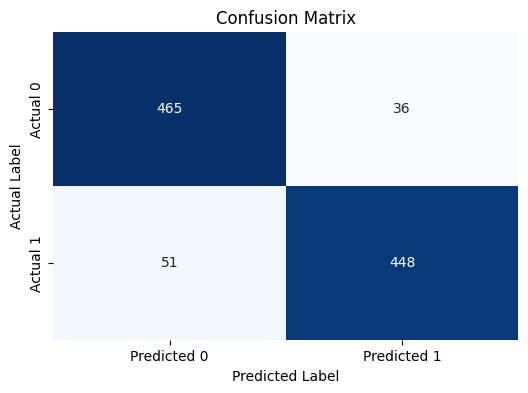

In [29]:
# Plot the confusion matrix

plt.figure(figsize=(6, 4));
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label');

Logistic Regression stands as a cornerstone in the realm of binary classification. Its strength lies in its simplicity, interpretability, and ability to provide probabilities for predictions. While it may not capture the most complex non-linear relationships as effectively as some advanced algorithms, its efficiency and the ease with which its parameters can be interpreted make it an invaluable tool for a wide array of real-world problems. It often serves as an excellent baseline model and remains a fundamental concept for anyone delving into machine learning.

## Regularized Linear Models

In machine learning, models, especially linear models, can sometimes suffer from **overfitting**. Overfitting occurs when a model learns the training data too well, capturing noise and specific patterns that don't generalize to new, unseen data. This results in excellent performance on the training set but poor performance on the test set.

**Regularization** is a technique used to combat overfitting by adding a penalty term to the cost (or loss) function. This penalty discourages the model from assigning excessively large weights to features, thereby simplifying the model and improving its generalization ability.

The core idea behind regularization is to strike a balance between fitting the training data well and keeping the model's complexity in check. It achieves this by penalizing the magnitude of the model's coefficients (weights).

### How Regularization is Implemented

Regularization works by modifying the standard cost function. Instead of just minimizing the error between predictions and actual values, we also minimize a function of the coefficients. The general form of a regularized cost function is:

$$J_{regularized}(\beta) = J_{original}(\beta) + \text{Regularization Term}$$

Here, $J_{original}(\beta)$ is the standard cost function (e.g., Mean Squared Error for linear regression, Log Loss for logistic regression), and the "Regularization Term" is what penalizes large coefficients. The strength of this penalty is controlled by a hyperparameter, typically denoted by $\lambda$ (lambda) or $\alpha$ (alpha). A larger $\lambda$ means a stronger penalty, leading to smaller coefficients and a simpler model.

There are two primary types of regularization commonly used: L1 and L2 regularization.

#### 1. L1 Regularization (Lasso Regression)

L1 regularization, or lasso ("least absolute shrinkage and selection operator") regression adds the **absolute value** of the magnitude of the coefficients to the cost function.

**Regularization Term:** $\lambda \sum_{j=1}^{n} |\beta_j|$

Where:
* $\lambda \ge 0$ is the regularization parameter.
* $\beta_j$ are the coefficients of the features.

L1 regularization has a unique property of driving some coefficients exactly to zero. This effectively performs **feature selection**, as features with zero coefficients are excluded from the model. This can be very useful for high-dimensional datasets where many features might be irrelevant.

#### 2. L2 Regularization (Ridge Regression)

L2 regularization adds the **squared magnitude** of the coefficients to the cost function.

**Regularization Term:** $\lambda \sum_{j=1}^{n} \beta_j^2$

Where:
* $\lambda \ge 0$ is the regularization parameter.
* $\beta_j$ are the coefficients of the features.

L2 regularization shrinks the coefficients towards zero but rarely makes them exactly zero. It penalizes large coefficients more severely due to the squaring effect.

It helps in cases of multicollinearity (highly correlated features) by distributing the weight among correlated features.

#### 3. Elastic Net Regularization

Elastic Net combines both L1 and L2 regularization. It includes both the sum of the absolute values and the sum of the squared values of the coefficients in the penalty term.

**Regularization Term:** $\lambda_1 \sum_{j=1}^{n} |\beta_j| + \lambda_2 \sum_{j=1}^{n} \beta_j^2$

Or, more commonly expressed with two hyperparameters, $\alpha$ (which controls the overall strength) and `l1_ratio` (which controls the mix between L1 and L2):

**Regularization Term:** $\alpha \left( (1 - \text{l1\_ratio}) \sum_{j=1}^{n} \beta_j^2 + \text{l1\_ratio} \sum_{j=1}^{n} |\beta_j| \right)$

It inherits the feature selection property of L1 and the coefficient shrinkage and stability of L2.

It is useful when there are groups of highly correlated features; Elastic Net tends to select all features in a correlated group, whereas Lasso might pick only one.

### Regularization in Linear Regression

For **Linear Regression**, the original cost function is Mean Squared Error (MSE):

$$J_{MSE}(\beta) = \frac{1}{m} \sum_{i=1}^{m} (h_\beta(x^{(i)}) - y^{(i)})^2$$

Where $h_\beta(x) = \beta_0 + \beta_1 x_1 + \dots + \beta_n x_n$.

* **Ridge Regression (L2 Linear Regression):**
    $$J_{Ridge}(\beta) = \frac{1}{m} \sum_{i=1}^{m} (h_\beta(x^{(i)}) - y^{(i)})^2 + \lambda \sum_{j=1}^{n} \beta_j^2$$

* **Lasso Regression (L1 Linear Regression):**
    $$J_{Lasso}(\beta) = \frac{1}{m} \sum_{i=1}^{m} (h_\beta(x^{(i)}) - y^{(i)})^2 + \lambda \sum_{j=1}^{n} |\beta_j|$$

The optimisation process is then applied to these modified cost functions to find the optimal $\beta$ values.

Lasso, Ridge, or Elastic Net regression can be implemented with Scikit-learn by importing `Lasso`, `Ridge`, or `ElasticNet` objects from it's `linear_model` module.


### Regularization in Logistic Regression

For **Logistic Regression**, the original cost function is Log Loss (Binary Cross-Entropy):

$$J_{LogLoss}(\beta) = -\frac{1}{m} \sum_{i=1}^{m} \left[ y^{(i)}\log(h_\beta(x^{(i)})) + (1 - y^{(i)})\log(1 - h_\beta(x^{(i)})) \right]$$

Where $h_\beta(x) = \frac{1}{1 + e^{-\mathbf{\beta}^T\mathbf{x}}}$.

* **L2 Regularized Logistic Regression:**
    $$J_{L2-LogReg}(\beta) = -\frac{1}{m} \sum_{i=1}^{m} \left[ y^{(i)}\log(h_\beta(x^{(i)})) + (1 - y^{(i)})\log(1 - h_\beta(x^{(i)})) \right] + \lambda \sum_{j=1}^{n} \beta_j^2$$

* **L1 Regularized Logistic Regression:**
    $$J_{L1-LogReg}(\beta) = -\frac{1}{m} \sum_{i=1}^{m} \left[ y^{(i)}\log(h_\beta(x^{(i)})) + (1 - y^{(i)})\log(1 - h_\beta(x^{(i)})) \right] + \lambda \sum_{j=1}^{n} |\beta_j|$$

L1, L2, or Elastic Net regularization can be implemented for Logistic Regression by modifying the `penalty`, `C`, and/or `l1_ratio` parameters of the `LogisticRegression` object.

In summary, regularization is a crucial technique for preventing overfitting in linear models (both regression and classification). By adding a penalty for large coefficients, it encourages simpler models that generalize better to unseen data, leading to more robust and reliable predictions.
